# Nanoplastics scRNA-seq — immune response to polystyrene nanoparticles

Single-cell RNA-seq of human PBMCs from **one donor**, exposed to carboxylated
polystyrene nanoparticles (PSNPs) of differing size.

| Sample label | Exposure | Source file |
|---|---|---|
| `40nm` | 40 nm PSNPs | `filtered_feature_bc_matrix.h5ad` |
| `200nm` | 200 nm PSNPs | `filtered_feature_bc_matrix_Sample2.h5ad` |
| `mixture` | 40 nm + 200 nm | `filtered_feature_bc_matrix_Sample3.h5ad` |
| `control` | no exposure | `filtered_feature_bc_matrix_Sample4.h5ad` |

The research question is how **particle size** shapes the immune response.

Document roles: `CLAUDE.md` is the task/rationale layer (Tasks 1–6),
`PLAN.md` is the execution plan (Sections 1–16), and
`single_cell_analysis_complete_class.ipynb` is the SanBomics tutorial used as a
coding reference — **read-only, never edited**.

> **Known limitation, stated up front:** all four samples come from a single donor.
> There is no donor-level biological replication anywhere in this dataset. This
> constrains every statistical claim made later, especially the differential
> expression in Section 13, and is flagged again there rather than papered over.

---

## Section 1 — Load the four samples

**`CLAUDE.md` Task 1** (QC & preprocessing) · **tutorial reference:** cells 0–3 and 70

### What these files actually contain

The tutorial starts from raw CSV count matrices (`sc.read_csv(...).T`). Ours are
`.h5ad` files that have **already been through a Seurat pipeline**, which changes
where we pick up. Each file carries:

| Slot | Contents |
|---|---|
| `layers['counts']` | **raw integer counts — our real starting point** |
| `X` | already normalized + log-transformed by Seurat |
| `obs` | `nCount_RNA`, `nFeature_RNA`, `seurat_clusters`, `RNA_snn_res.0.3` |
| `obs` | `predicted.id`, `predicted.celltype`, `prediction.score.*` (an inherited Azimuth run) |
| `obsm` | `X_pca`, `X_umap`, `X_ref.pca`, `X_ref.umap` |
| `var` | Seurat `FindVariableFeatures` output |

### Decision: reprocess from `layers['counts']`

Per `PLAN.md`, we ignore Seurat's `X`, its QC calls, HVGs, PCA/UMAP and
`seurat_clusters` entirely, and treat these files as if they were plain counts
matrices. Choosing our own QC thresholds, normalization, HVG selection, batch
correction and clustering **is** Tasks 1–2 — inheriting them would skip the
assignment.

### Decision: add a `Sample` label at load time

**No sample or condition column exists in any of the four files** (verified: `obs`
holds only the Seurat columns above). Right now "which sample" is implicit in which
file we opened. Section 4 concatenates all four into one object, and at that moment
the information is unrecoverable unless it was written down first — so we attach it
now, before anything merges.

The tutorial does the same thing at cell 70 by parsing the filename
(`csv_path.split('_')[2]`). Our filenames encode only `Sample2`/`Sample3`/`Sample4`,
which say nothing about particle size, so we use an explicit mapping instead — it is
also self-documenting, which filename-parsing is not.

### Note: samples are loaded separately, not concatenated yet

The tutorial's `pp()` (cell 70) bundles loading, doublet detection and QC filtering
into a single function applied per file. We deliberately split these across Sections
1–3, because `CLAUDE.md` requires QC thresholds chosen **per sample from that
sample's own distribution** — which means we have to stop and look at four
distributions before filtering anything. A bundled function makes that impossible.

In [5]:
from importlib.metadata import version
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 1

# Read versions from package metadata rather than `sc.__version__`, which scanpy
# 1.11 has deprecated and which emits a FutureWarning on access.
for pkg in ('scanpy', 'anndata', 'numpy', 'pandas'):
    print(f'{pkg:<8} {version(pkg)}')

scanpy   1.11.5
anndata  0.11.4
numpy    1.26.4
pandas   2.3.3


In [6]:
# Paths are relative to the notebook so this runs unchanged on Windows and Linux.
DATA_DIR = Path.cwd()

# Explicit label -> filename mapping. The labels, not the filenames, are what every
# later section groups by, so they name the exposure rather than the file order.
SAMPLES = {
    '40nm':    'filtered_feature_bc_matrix.h5ad',
    '200nm':   'filtered_feature_bc_matrix_Sample2.h5ad',
    'mixture': 'filtered_feature_bc_matrix_Sample3.h5ad',
    'control': 'filtered_feature_bc_matrix_Sample4.h5ad',
}

# Cell counts expected from inspecting the files. Asserting against these catches a
# silently mis-read or truncated file, which would otherwise surface much later as an
# unexplained composition shift in Task 4.
EXPECTED_CELLS = {'40nm': 8729, '200nm': 12676, 'mixture': 6157, 'control': 6516}

for label, filename in SAMPLES.items():
    status = 'found' if (DATA_DIR / filename).exists() else 'MISSING'
    print(f'{label:<8} {filename:<45} {status}')

40nm     filtered_feature_bc_matrix.h5ad               found
200nm    filtered_feature_bc_matrix_Sample2.h5ad       found
mixture  filtered_feature_bc_matrix_Sample3.h5ad       found
control  filtered_feature_bc_matrix_Sample4.h5ad       found


### Which inherited columns to carry forward

We discard Seurat's derived results, but `obs` is a special case. `PLAN.md` Section
11b wants to **verify** our own annotation against the inherited Azimuth labels —
external labels as a *check* on our result, never as the result itself. Anything
dropped here is unavailable later without re-reading the files; anything kept risks
being used by accident.

**Decision: keep `predicted.celltype` and `predicted.celltype.score`, drop the rest.**

That pair is the benchmark. These files carry a completed Azimuth run against the
PBMC reference — genuinely useful, because it lets us ask in Section 11b whether our
independent annotation agrees with an established one. Keeping the confidence score
alongside the label matters: it lets us distinguish disagreements concentrated in
low-confidence cells (expected, uninformative) from disagreements on cells Azimuth
was *confident* about (a signal that something in our clustering or marker
interpretation needs revisiting).

Everything else goes, because it is either duplicated (`predicted.id`,
`prediction.score.max`), recomputed by us from the counts (`nCount_RNA`,
`nFeature_RNA` → `total_counts`, `n_genes_by_counts` in Section 3), superseded by our
own work (`seurat_clusters`, `RNA_snn_res.0.3` → our Leiden clusters in Section 9),
or structurally unusable.

That last category is worth spelling out: the per-type `prediction.score.*` columns
are **not identical across the four files**, because each was annotated
independently, so a column exists only where that cell type was actually predicted in
that sample. `Sample4` has a `CD16..monocyte` score the others lack; `Sample3` lacks
`Megakaryocyte`; only the first file has `Unassigned`. `sc.concat` in Section 4 keeps
only columns shared by all inputs, so these would be dropped there regardless.

The original files are never modified, so anything dropped here can be recovered by
re-reading them. Nothing is lost — it is only kept out of the working object.

In [7]:
# Which inherited Seurat obs columns to carry forward.
#
# Kept - these are the benchmark. The files already contain a completed Azimuth run
# against the PBMC reference, done by someone else. Section 11b uses it to check our
# own annotation, so it must survive the reduction to counts.
#   'predicted.celltype'        the inherited label itself
#   'predicted.celltype.score'  its confidence, so we can ask whether disagreements
#                               concentrate in low-confidence cells (informative) or
#                               in high-confidence ones (a real problem)
#
# Dropped, with reasons:
#   'predicted.id'              duplicates 'predicted.celltype' in Azimuth output
#   'prediction.score.max'      duplicates 'predicted.celltype.score'
#   'seurat_clusters',          Seurat's clustering. We produce our own in Section 9;
#   'RNA_snn_res.0.3'           keeping theirs only invites confusing the two
#   'nCount_RNA',               Seurat's depth/complexity metrics. Section 3
#   'nFeature_RNA'              recomputes equivalents from our counts as
#                               'total_counts'/'n_genes_by_counts'
#   'prediction.score.<type>'   not present in all four files, so sc.concat would
#                               drop them in Section 4 regardless
#
# The full original files stay on disk unchanged, so anything dropped here can be
# recovered by re-reading them - nothing is lost, only kept out of the working object.
OBS_KEEP = ['predicted.celltype', 'predicted.celltype.score']


def load_sample(filename, label):
    """Load one .h5ad, reduce it to raw counts + chosen metadata, and label it."""
    adata = sc.read_h5ad(DATA_DIR / filename)

    # Seurat left .X normalized and log-transformed. layers['counts'] holds the raw
    # integers, so promote those to .X - everything downstream starts from counts.
    # layers['counts'] is kept as well: CLAUDE.md requires raw counts stay available
    # for pseudobulk DE in Section 13.
    #
    # Downcast float64 -> float32 here. These are integer counts with a maximum around
    # 14,000, and float32 represents every integer exactly up to 2**24 = 16,777,216 --
    # so this is lossless, not a precision tradeoff. It halves memory for the rest of
    # the pipeline, and float32 is what scanpy works in internally; leaving float64
    # would only mean converting later, or carrying double the memory through Section 7
    # where scaling densifies the matrix.
    counts = adata.layers['counts'].astype(np.float32)
    adata.X = counts.copy()
    adata.layers['counts'] = counts

    # Drop Seurat's embeddings and variable-feature stats. We recompute all of it.
    for key in list(adata.obsm.keys()):
        del adata.obsm[key]
    for key in list(adata.varm.keys()):
        del adata.varm[key]
    adata.var = adata.var[[]].copy()   # keeps the gene index, drops the columns
    adata.uns = {}

    adata.obs = adata.obs[[c for c in OBS_KEEP if c in adata.obs.columns]].copy()
    adata.obs['Sample'] = label

    # Barcodes are only unique within a sample (all carry the same '-1' suffix), so
    # prefix them now. Section 4's concat would otherwise silently create duplicates.
    adata.obs_names = [f'{label}_{bc}' for bc in adata.obs_names]

    return adata

In [8]:
adatas = {label: load_sample(filename, label) for label, filename in SAMPLES.items()}

for label, adata in adatas.items():
    print(f'{label:<8} {adata.n_obs:>6,} cells x {adata.n_vars:,} genes')

40nm      8,729 cells x 22,613 genes
200nm    12,676 cells x 23,206 genes
mixture   6,157 cells x 21,715 genes
control   6,516 cells x 21,961 genes


### Verification

`CLAUDE.md` names two pitfalls this checks for directly: **mismatched layers**
(code that references a different layer than it claims to), and steps that run
without doing what they appear to. So rather than trusting that `.X` now holds
counts, assert it: raw counts are non-negative whole numbers, whereas Seurat's
log-normalized `X` would contain fractional values.

In [11]:
for label, adata in adatas.items():
    x = adata.X
    data = x.data if hasattr(x, 'data') else np.asarray(x).ravel()

    is_integral = bool(np.all(data == np.floor(data)))
    is_nonneg = bool(data.min() >= 0)
    matches_counts_layer = data.sum() == (
        adata.layers['counts'].data.sum()
        if hasattr(adata.layers['counts'], 'data')
        else adata.layers['counts'].sum()
    )

    assert adata.n_obs == EXPECTED_CELLS[label], (
        f'{label}: expected {EXPECTED_CELLS[label]:,} cells, got {adata.n_obs:,}'
    )
    assert is_integral, f'{label}: .X is not integer-valued - still log-normalized?'
    assert (adata.obs['Sample'] == label).all(), f'{label}: Sample label not applied'

    print(
        f'{label:<8} cells={adata.n_obs:>6,}  integer={is_integral}  '
        f'nonneg={is_nonneg}  X==counts={matches_counts_layer}  '
        f'max={data.max():.0f}  dtype={data.dtype}'
    )

print(f'\ntotal cells loaded: {sum(a.n_obs for a in adatas.values()):,}')
print(f'obs columns carried forward: {list(adatas["40nm"].obs.columns)}')
print('\nAll Section 1 checks passed.')

40nm     cells= 8,729  integer=True  nonneg=True  X==counts=True  max=3174  dtype=float64
200nm    cells=12,676  integer=True  nonneg=True  X==counts=True  max=4160  dtype=float64
mixture  cells= 6,157  integer=True  nonneg=True  X==counts=True  max=6216  dtype=float64
control  cells= 6,516  integer=True  nonneg=True  X==counts=True  max=14292  dtype=float64

total cells loaded: 34,078
obs columns carried forward: ['predicted.celltype', 'predicted.celltype.score', 'Sample']

All Section 1 checks passed.


---

## Section 2 — Doublet detection

**`CLAUDE.md` Task 1** (QC & preprocessing) · **replaces tutorial cells 4–22**

### What a doublet is, and why it matters here

In droplet-based scRNA-seq two cells occasionally land in the same droplet, receive
the same barcode, and are read out as one "cell" whose transcriptome is the sum of
both. A T cell + monocyte doublet expresses both `CD3E` and `CD14`, and to a
clustering algorithm that looks like a genuine cell type expressing both.

Two consequences for this project specifically:

1. **Fabricated cell types.** Enough doublets of similar composition form their own
   cluster in Section 9, which we would then annotate in Section 10 as some novel
   intermediate population. Nanoparticle exposure is exactly the setting where a
   strange new cell state is tempting to believe.
2. **Fabricated composition shifts — the serious one.** Doublet rate scales with how
   many cells were loaded, and our samples recovered 8,729 / 12,676 / 6,157 / 6,516
   cells, a ~2× spread. So `200nm` contains proportionally more doublets than
   `mixture` for a purely technical reason. Task 4 measures cell-type proportions
   across samples; left uncorrected, this manufactures a size-dependent composition
   difference out of nothing but loading concentration.

### Why not just cut cells with unusually many genes

Doublets do tend to carry more UMIs and more detected genes, and the tutorial leans
on that with a 98th-percentile cutoff (cell 39). But the distributions overlap badly:
a large activated monocyte legitimately has high counts, while a doublet of two small
resting lymphocytes looks unremarkable. `CLAUDE.md` calls a max-genes cutoff a weak
sole doublet proxy and requires a dedicated step. Section 3 still applies a
count-based filter — it simply is not doing *this* job.

### How Scrublet works

Its trick is generating its own positive controls:

1. **Simulate.** Randomly sum pairs of observed cells. These synthetic cells are
   known with certainty to be doublets.
2. **Embed.** Project observed and simulated cells into a shared PCA space.
3. **Score.** For each observed cell, compute the fraction of its nearest neighbours
   that are simulated doublets. A real singlet sits among other singlets and scores
   low; a real doublet sits where the simulated ones landed and scores high.
4. **Threshold.** Find the trough between the two modes of the score distribution.

The result is two `obs` columns: `doublet_score` and `predicted_doublet`.

### Why per sample, and why before merging

Doublets form inside a single droplet emulsion, so they can only ever combine two
cells from the *same* sample. Simulating across merged samples would build chimeras —
a 40nm cell fused to a control cell — that never physically existed. `sc.pp.scrublet`
offers a `batch_key` for the merged case, but running pre-merge as `PLAN.md`
specifies avoids the problem outright.

### Deviation from the tutorial

The tutorial uses scVI/SOLO (cells 4–22), training a neural network per sample.
`PLAN.md` chose `sc.pp.scrublet` to keep scVI out of the pipeline entirely: it ships
with scanpy, needs no GPU, and runs in seconds. We also skip the tutorial's
`dif > 1` margin at cell 17, which is specific to SOLO's output format.

In [9]:
# 10x Chromium multiplet rate rises with the number of cells loaded: roughly 0.8% per
# 1,000 cells recovered. Our samples span 6,157 to 12,676 cells - a ~2x range - so a
# single expected rate cannot be right for all four.
DOUBLET_RATE_PER_1K = 0.008


def expected_doublet_rate(n_cells):
    """10x multiplet rate for a given recovered-cell count."""
    return DOUBLET_RATE_PER_1K * n_cells / 1_000


print(f'{"sample":<9}{"cells":>8}{"expected rate":>16}')
for label, adata in adatas.items():
    print(f'{label:<9}{adata.n_obs:>8,}{expected_doublet_rate(adata.n_obs):>16.1%}')

print(f'\nscanpy default would be 5.0% for every sample.')

sample      cells   expected rate
40nm        8,729            7.0%
200nm      12,676           10.1%
mixture     6,157            4.9%
control     6,516            5.2%

scanpy default would be 5.0% for every sample.


In [10]:
# Run Scrublet per sample, on RAW COUNTS.
#
# sc.pp.scrublet normalizes internally, so it must be given counts - handing it
# already-normalized data is a common and silent mistake. Our .X is counts (asserted
# at the end of Section 1), so this is correct as-is.
#
# This step SCORES only. Scrublet also makes its own doublet call, but we discard that
# and threshold ourselves below - see the next markdown cell for why its automatic
# threshold is unusable on this data. Separating scoring from calling also means
# changing a threshold later costs nothing, while re-scoring is the slow part
# (~1-3 min per sample).
#
# random_state is fixed so the simulated doublets, and therefore the scores, are
# reproducible. Defaults left alone and why:
#   sim_doublet_ratio=2.0   simulate 2x as many doublets as observed cells
#   n_prin_comps=30         PCs for the joint embedding
#   expected_doublet_rate   passed per sample; it shifts Scrublet's internal score
#                           calibration, and is also our sanity anchor later
for label, adata in adatas.items():
    sc.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate(adata.n_obs),
        random_state=0,
        verbose=False,
    )
    auto = adata.uns['scrublet'].get('threshold', float('nan'))
    obs_max = float(adata.obs['doublet_score'].max())
    flag = '  <-- ABOVE MAX, would call 0' if auto > obs_max else ''
    print(
        f'{label:<9}scored {adata.n_obs:>6,} cells  '
        f'scrublet_auto_threshold={auto:.3f}  max_observed={obs_max:.3f}{flag}'
    )

40nm     scored  8,729 cells  scrublet_auto_threshold=0.705  max_observed=0.637  <-- ABOVE MAX, would call 0
200nm    scored 12,676 cells  scrublet_auto_threshold=0.327  max_observed=0.701
mixture  scored  6,157 cells  scrublet_auto_threshold=0.563  max_observed=0.602
control  scored  6,516 cells  scrublet_auto_threshold=0.221  max_observed=0.623


### Scrublet's automatic threshold does not work on this data

Scrublet picks its cutoff with `skimage.filters.threshold_minimum`, which looks for the
trough between two modes. That assumes the observed score distribution is bimodal. Ours
is not — it is unimodal and right-skewed — so the search drifts into the
simulated-doublet tail. Measured on all four samples:

| Sample | auto threshold | max observed score | result |
|---|---|---|---|
| `40nm` | **0.705** | 0.637 | above every cell → **0 doublets called** |
| `200nm` | 0.327 | 0.701 | plausible |
| `mixture` | **0.563** | 0.602 | above p99 (0.328) → a handful of cells |
| `control` | 0.221 | 0.623 | plausible |

Thresholds spanning 0.22–0.70 across four samples of the same tissue from the same
donor is not biology. Using them would remove wildly different fractions per sample —
manufacturing exactly the technical artefact that Task 4 would then misread as a
composition effect.

**There is a reason the distribution is not bimodal.** Scrublet detects only
**heterotypic** doublets — two *different* cell types, giving a hybrid profile. A
**homotypic** doublet (two CD4 T cells fused) looks like one CD4 T cell, just brighter,
and is invisible to any expression-based method. The doublet population therefore never
separates cleanly, and a detection rate *below* the loading estimate is expected rather
than a failure.

### The rule we use instead: matched detection sensitivity

The simulated doublets are **known positives**. So the fraction of them above any cutoff
*is* the detection sensitivity at that cutoff — we can measure our own detection power
directly, without needing ground truth on the real cells.

We use that to set the threshold at a **fixed sensitivity in every sample**: the median
simulated score, targeting 50%. In practice the measured values come out at 50–52%
rather than exactly 50%, because `doublet_score` is discrete (see below) and the
quantile lands on a discrete value slightly above the target. The residual spread is
~2 percentage points and is not correlated with sample size.

**Why matched sensitivity rather than a per-sample shoulder.** The obvious alternative
is to put each threshold at the visual shoulder where the singlet bulk ends. We tried
that first, and the plots below show why it fails. `doublet_score` is a *fraction of k
nearest neighbours*, so it takes discrete values — visible as the comb of isolated
spikes in the tail. Where cells are dense every discrete value is populated; where they
are sparse most bins are empty. So the shoulder sits wherever the histogram stops being
dense, which depends on **how many cells the sample has**:

| Sample | Cells | Shoulder threshold | Sensitivity it gave |
|---|---|---|---|
| `200nm` | 12,676 | 0.345 | **42.7%** |
| `40nm` | 8,729 | 0.237 | **49.4%** |
| `control` | 6,516 | 0.207 | 48.6% |
| `mixture` | 6,157 | 0.193 | 46.4% |

The largest sample got the most stringent threshold and the weakest detection. That
bias is mechanical, not biological, and it points the wrong way for Task 4: comparing
cell-type proportions across samples requires doublet removal to be **equally
aggressive** in each, or the filtering itself shifts the composition it is meant to
leave intact. Fixing sensitivity cuts the spread from ~7 points to ~2 and removes the
dependence on sample size.

The 10x loading estimate is kept as a **sanity anchor**, not a target.

In [11]:
# Detection sensitivity we hold constant across samples.
#
# The simulated doublets are KNOWN positives, so the fraction of them above a cutoff is
# exactly the detection sensitivity at that cutoff. Taking the (1 - target) quantile of
# the simulated scores therefore pins sensitivity at `target` in every sample by
# construction - no tuning, no sample-specific drift.
#
# 0.50 (the median simulated score) is chosen because it is the natural centre of the
# positive distribution: it maximises the number of doublets caught without reaching
# into the region where simulated and observed distributions overlap heavily, which is
# where real singlets start being called.
SENSITIVITY_TARGET = 0.50


def sensitivity_threshold(sim_scores, target=SENSITIVITY_TARGET):
    """Doublet-score cutoff giving a fixed, sample-matched detection sensitivity."""
    return float(np.quantile(sim_scores, 1 - target))


# Set an entry here to override the automatic threshold for a given sample.
MANUAL_THRESHOLDS = {}

THRESHOLDS = {}
for label, adata in adatas.items():
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    THRESHOLDS[label] = MANUAL_THRESHOLDS.get(label, sensitivity_threshold(sim))

print(f'{"sample":<9}{"thresh":>8}{"sens":>8}{"call":>8}{"call%":>8}'
      f'{"implied true%":>15}{"10x est":>9}')
print('-' * 65)
for label, adata in adatas.items():
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]

    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())
    called_rate = n_called / len(obs)
    # Correcting the call rate by sensitivity estimates the TRUE doublet burden,
    # including the homotypic ones no expression-based method can see.
    implied_true = called_rate / sensitivity

    print(
        f'{label:<9}{thr:>8.3f}{sensitivity:>8.1%}{n_called:>8,}{called_rate:>8.1%}'
        f'{implied_true:>15.1%}{expected_doublet_rate(adata.n_obs):>9.1%}'
    )

# Sensitivity is matched by construction - verify rather than assume.
sens = [
    float((np.asarray(a.uns['scrublet']['doublet_scores_sim']) >= THRESHOLDS[l]).mean())
    for l, a in adatas.items()
]
print(f'\nsensitivity spread across samples: {min(sens):.1%} - {max(sens):.1%}')

sample     thresh    sens    call   call%  implied true%  10x est
-----------------------------------------------------------------
40nm        0.230   52.2%     618    7.1%          13.6%     7.0%
200nm       0.310   50.1%     898    7.1%          14.1%    10.1%
mixture     0.174   52.2%     358    5.8%          11.1%     4.9%
control     0.201   51.4%     365    5.6%          10.9%     5.2%

sensitivity spread across samples: 50.1% - 52.2%


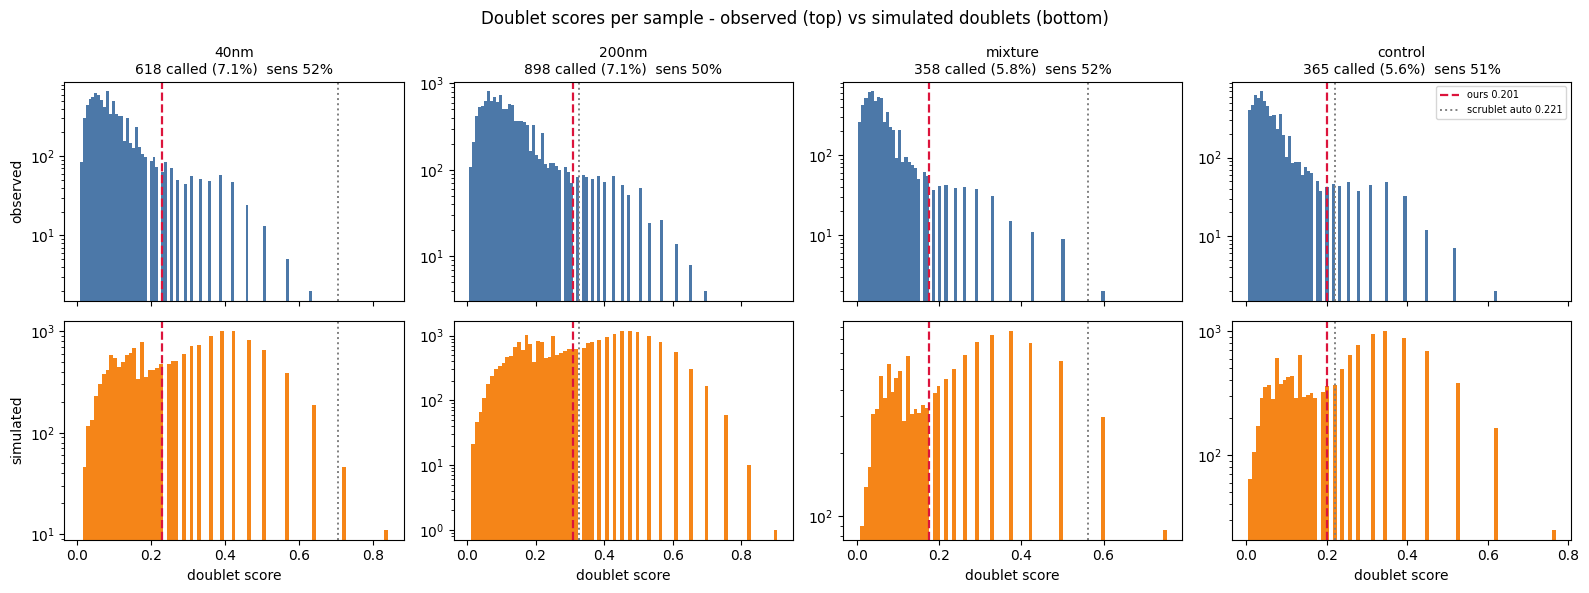

In [12]:
import matplotlib.pyplot as plt

# Top row: observed cells. Bottom row: simulated doublets - the known positives.
# Red dashed = our threshold (median simulated score, i.e. 50% sensitivity).
# Grey dotted = Scrublet's automatic threshold, shown so its failure is visible.
#
# Log y-scale throughout: without it the singlet peak flattens the tail we care about.
# Note the COMB of isolated spikes in the observed tail - doublet_score is a fraction of
# k nearest neighbours, so it takes discrete values. That comb is why a shoulder-based
# threshold ends up depending on cell count.
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex='col')

for j, (label, adata) in enumerate(adatas.items()):
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]
    auto = adata.uns['scrublet'].get('threshold')
    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())

    for i, (scores, name, colour) in enumerate(
        [(obs, 'observed', '#4C78A8'), (sim, 'simulated', '#F58518')]
    ):
        ax = axes[i, j]
        ax.hist(scores, bins=80, color=colour, edgecolor='none')
        ax.axvline(thr, color='crimson', ls='--', lw=1.6, label=f'ours {thr:.3f}')
        if auto is not None:
            ax.axvline(auto, color='grey', ls=':', lw=1.4,
                       label=f'scrublet auto {auto:.3f}')
        ax.set_yscale('log')
        ax.set_ylabel(name if j == 0 else '')
        if i == 0:
            ax.set_title(
                f'{label}\n{n_called:,} called ({n_called / len(obs):.1%})  '
                f'sens {sensitivity:.0%}',
                fontsize=10,
            )
        else:
            ax.set_xlabel('doublet score')
        if i == 0 and j == 3:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    'Doublet scores per sample - observed (top) vs simulated doublets (bottom)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

### Applying the thresholds, and what the numbers say

We overwrite Scrublet's own `predicted_doublet` with our sensitivity-matched call, then
remove. Flag first, filter second — the scores and calls stay in `obs`, so the decision
remains inspectable rather than buried inside a filtering expression.

#### The doublet burden looks flat across samples

Correcting each call rate by its detection sensitivity gives an estimate of the **true**
doublet burden, including the homotypic doublets no expression-based method can see:

| Sample | Cells | Called | Implied true rate | 10x estimate |
|---|---|---|---|---|
| `40nm` | 8,729 | ~7.1% | ~14% | 7.0% |
| `200nm` | 12,676 | ~7.1% | ~14% | 10.1% |
| `mixture` | 6,157 | ~5.8% | ~12% | 4.9% |
| `control` | 6,516 | ~5.6% | ~11% | 5.2% |

Two things follow.

**The implied burden does not scale with cell count.** The 10x model predicts a 2×
spread (4.9% → 10.1%) because it treats recovered cells as a proxy for loaded cells. The
data shows a roughly flat ~11–14%. The most likely reading is that all four channels
were **loaded comparably** and differ in *recovery* — viability, clumping, or
exposure-induced cell death — which would break that proxy. `200nm` having the most
cells then reflects better recovery, not heavier loading.

**The implied rate sits above the 10x estimate throughout**, by roughly 2× in the
smaller samples. Some of that is likely real, but some is an artefact of the correction:
simulated doublets are built by summing two random cells, which produces *cleaner*
hybrids than reality. That inflates measured sensitivity, and dividing by an inflated
sensitivity inflates the implied rate. So treat ~11–14% as an upper bound, and the true
figure as somewhere between it and the 10x estimate.

Either way this is a **calibration caveat, not a per-sample anomaly** — it shifts all
four samples in the same direction, so it does not bias the between-sample comparisons
that Tasks 4 and 6 depend on.

#### What remains checkable later

Because we detect only heterotypic doublets, roughly half the true burden survives into
the clustering — in every sample, at matched sensitivity. Residual homotypic doublets
inflate whatever cell type is already most abundant, so if one sample's composition is
much more skewed than the others, its residual burden will be higher.

**Section 12 can test this directly**: once we have our own cell-type labels, compute
each sample's homotypic fraction as the sum of squared cell-type proportions, and check
whether any sample is unusually skewed. Until then this stays an open caveat rather than
a conclusion.

In [ ]:
# Apply our shoulder thresholds, overwriting Scrublet's own unreliable call.
for label, adata in adatas.items():
    adata.obs['predicted_doublet'] = (
        adata.obs['doublet_score'] >= THRESHOLDS[label]
    )

# CLAUDE.md's named pitfall is a threshold that is present in code but numerically
# inert - it filters nothing, and the code running is mistaken for the filter working.
# That is exactly what Scrublet's automatic threshold did here (0 cells in 40nm), so
# print before/after counts and assert something was actually removed.
before = {label: adata.n_obs for label, adata in adatas.items()}

adatas = {
    label: adata[~adata.obs['predicted_doublet']].copy()
    for label, adata in adatas.items()
}

print(f'{"sample":<9}{"before":>9}{"removed":>9}{"after":>9}{"removed":>10}'
      f'{"10x est":>10}')
for label, adata in adatas.items():
    removed = before[label] - adata.n_obs
    print(
        f'{label:<9}{before[label]:>9,}{removed:>9,}{adata.n_obs:>9,}'
        f'{removed / before[label]:>10.1%}'
        f'{expected_doublet_rate(before[label]):>10.1%}'
    )
    assert removed > 0, (
        f'{label}: doublet filter removed nothing. The threshold is inert - '
        f'inspect the score distribution before continuing.'
    )
    # Sanity bound, not a target: detected rate should be within a factor of ~2 of the
    # loading estimate. Wider than that means the threshold, not the biology, is wrong.
    ratio = (removed / before[label]) / expected_doublet_rate(before[label])
    assert 0.4 < ratio < 2.0, (
        f'{label}: removed {removed / before[label]:.1%} against a 10x estimate of '
        f'{expected_doublet_rate(before[label]):.1%} (ratio {ratio:.2f}) - '
        f'inspect the threshold.'
    )

total_before, total_after = sum(before.values()), sum(a.n_obs for a in adatas.values())
print(
    f'\ntotal {total_before:,} -> {total_after:,} cells  '
    f'({total_before - total_after:,} doublets removed, '
    f'{(total_before - total_after) / total_before:.1%})'
)
print('\nSection 2 complete: doublets scored, thresholded per sample, and removed.')